# SVM Classification Model — Inventory Waste & Production Inefficiency

**Business Problem:**
- Flange material wastage (GI items)
- PI phenolic sheet wastage
- Incorrect cutting by labor workers

**Classification Targets:**
1. Waste Level → Low Waste vs High Waste
2. Material Type → GI vs PI

## Cell 1 — Imports

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve
)
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")
print("All libraries imported successfully.")

All libraries imported successfully.


## Cell 2 — Load Data

In [22]:
print("LOADING DATA")

df_main = pd.read_csv("../data/Inventory_Waste_CompanyData.csv")
df_gi   = pd.read_csv("../data/GI_ITEM_LIST.csv")
df_pi   = pd.read_csv("../data/PI_ITEM_LIST.csv")

print(f"Main dataset shape      : {df_main.shape}")
print(f"GI item list shape      : {df_gi.shape}")
print(f"PI item list shape      : {df_pi.shape}")
print()
print("Main dataset columns:\n", df_main.dtypes)
print()
df_main.head()

LOADING DATA
Main dataset shape      : (2000, 7)
GI item list shape      : (1500, 9)
PI item list shape      : (1500, 8)

Main dataset columns:
 Job ID                  object
Material Type           object
Area (sq/m)            float64
Thickness (mm)         float64
Material Cost (AED)    float64
Waste Percentage       float64
Waste Cost (AED)       float64
dtype: object



,Job ID,Material Type,Area (sq/m),Thickness (mm),Material Cost (AED),Waste Percentage,Waste Cost (AED)
0,JOB_1,PI,68.64,20.0,2186.09,0.1750,382.57
1,JOB_2,GI,58.88,0.7,1017.49,0.0244,24.83
2,JOB_3,GI,35.81,0.7,630.32,0.0725,45.70
3,JOB_4,GI,14.00,1.1,380.97,0.1782,67.89
4,JOB_5,PI,15.80,25.0,634.38,0.1898,120.41


## Cell 3 — Enrich with Item List Statistics

In [23]:
gi_avg_unit_cost = df_gi["Unit Cost"].mean()
pi_avg_cost      = df_pi["Purchase Cost"].mean()

gi_raw_count = df_gi[df_gi["Product Category"].str.strip() == "Raw-Material"].shape[0]
pi_raw_count = df_pi[df_pi["Product Category"].str.strip() == "Raw-Material"].shape[0]
gi_consumable_count = df_gi[df_gi["Product Category"].str.strip() == "Consumable"].shape[0]

print(f"GI Avg Unit Cost        : {gi_avg_unit_cost:.2f}")
print(f"PI Avg Purchase Cost    : {pi_avg_cost:.2f}")
print(f"GI Raw-Material items   : {gi_raw_count}")
print(f"PI Raw-Material items   : {pi_raw_count}")

df_main["Avg_Item_Cost"] = df_main["Material Type"].map({
    "GI": gi_avg_unit_cost,
    "PI": pi_avg_cost
})
df_main["Raw_Material_Item_Count"] = df_main["Material Type"].map({
    "GI": gi_raw_count,
    "PI": pi_raw_count
})
print("\nEnrichment features added.")

GI Avg Unit Cost        : 14.09
PI Avg Purchase Cost    : 23.97
GI Raw-Material items   : 327
PI Raw-Material items   : 100

Enrichment features added.


## Cell 4 — Feature Engineering

In [24]:
print("FEATURE ENGINEERING")

#Derived features
df_main["Cost_Per_SqM"]   = df_main["Material Cost (AED)"] / df_main["Area (sq/m)"]
df_main["Thickness_Area"] = df_main["Thickness (mm)"]       * df_main["Area (sq/m)"]

#TARGET 1: Waste Level (Low vs High)
waste_median = df_main["Waste Percentage"].median()
df_main["Waste_Level"] = (df_main["Waste Percentage"] > waste_median).astype(int)
print(f"Waste Percentage median (threshold): {waste_median:.2f}")
print(df_main["Waste_Level"].value_counts().rename({0: "Low Waste", 1: "High Waste"}))

#TARGET 2: Material Type
le = LabelEncoder()
df_main["Material_Type_Enc"] = le.fit_transform(df_main["Material Type"])
print(f"\nMaterial Type classes   : {dict(zip(le.classes_, le.transform(le.classes_)))}")

FEATURE_COLS = [
    "Area (sq/m)",
    "Thickness (mm)",
    "Material Cost (AED)",
    "Cost_Per_SqM",
    "Thickness_Area",
    "Avg_Item_Cost",
    "Raw_Material_Item_Count",
]

FEATURE_COLS_MT = [
    "Area (sq/m)",
    "Thickness (mm)",
    "Material Cost (AED)",
    "Cost_Per_SqM",
    "Thickness_Area",
]

print(f"\nWaste Level features : {FEATURE_COLS}")
print(f"Material Type features : {FEATURE_COLS_MT}")

FEATURE ENGINEERING
Waste Percentage median (threshold): 0.10
Waste_Level
High Waste    1000
Low Waste     1000
Name: count, dtype: int64

Material Type classes   : {'GI': np.int64(0), 'PI': np.int64(1)}

Waste Level features : ['Area (sq/m)', 'Thickness (mm)', 'Material Cost (AED)', 'Cost_Per_SqM', 'Thickness_Area', 'Avg_Item_Cost', 'Raw_Material_Item_Count']
Material Type features : ['Area (sq/m)', 'Thickness (mm)', 'Material Cost (AED)', 'Cost_Per_SqM', 'Thickness_Area']


## Cell 5 — SVM Training Helper Function

In [ ]:
def train_evaluate_svm(X, y, target_name, class_names, tune_hyperparams=True):
    print(f"SVM MODEL → Target: {target_name}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("svm",    SVC(probability=True, random_state=42))
    ])

    if tune_hyperparams:
        param_grid = {
            "svm__C":      [0.1, 1, 10, 100],
            "svm__gamma":  ["scale", "auto", 0.001, 0.01],
            "svm__kernel": ["rbf", "linear", "poly"],
        }
        print("\nRunning GridSearchCV (this may take a moment)...")
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        grid_search = GridSearchCV(
            pipeline, param_grid,
            cv=cv, scoring="accuracy", n_jobs=-1, verbose=0
        )
        grid_search.fit(X_train, y_train)
        best_model = grid_search.best_estimator_
        print(f"Best Params             : {grid_search.best_params_}")
        print(f"Best CV Accuracy        : {grid_search.best_score_:.4f}")
    else:
        best_model = pipeline
        best_model.fit(X_train, y_train)

    y_pred      = best_model.predict(X_test)
    y_pred_prob = best_model.predict_proba(X_test)

    print("\nClassification Report")
    print(classification_report(y_test, y_pred, target_names=class_names))

    cv_scores = cross_val_score(best_model, X, y, cv=5, scoring="accuracy")
    print(f"5-Fold CV Accuracy      : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

    if len(class_names) == 2:
        auc = roc_auc_score(y_test, y_pred_prob[:, 1])
        print(f"ROC-AUC Score           : {auc:.4f}")
    else:
        auc = roc_auc_score(y_test, y_pred_prob, multi_class="ovr")
        print(f"ROC-AUC (OvR)           : {auc:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"SVM Results — {target_name}", fontsize=14, fontweight="bold")

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
    axes[0].set_title("Confusion Matrix")

    if len(class_names) == 2:
        fpr, tpr, _ = roc_curve(y_test, y_pred_prob[:, 1])
        axes[1].plot(fpr, tpr, color="royalblue", lw=2, label=f"AUC = {auc:.4f}")
        axes[1].plot([0, 1], [0, 1], "k--", lw=1)
        axes[1].set_xlabel("False Positive Rate")
        axes[1].set_ylabel("True Positive Rate")
        axes[1].set_title("ROC Curve")
        axes[1].legend(loc="lower right")
    else:
        axes[1].axis("off")
        axes[1].text(0.5, 0.5, f"ROC-AUC (OvR) = {auc:.4f}",
                     ha="center", va="center", fontsize=14)

    plt.tight_layout()
    plt.show()

    return best_model

print("SVM helper function defined.")

SVM helper function defined.


## Cell 6 — Exploratory Data Analysis (EDA)

EXPLORATORY DATA ANALYSIS


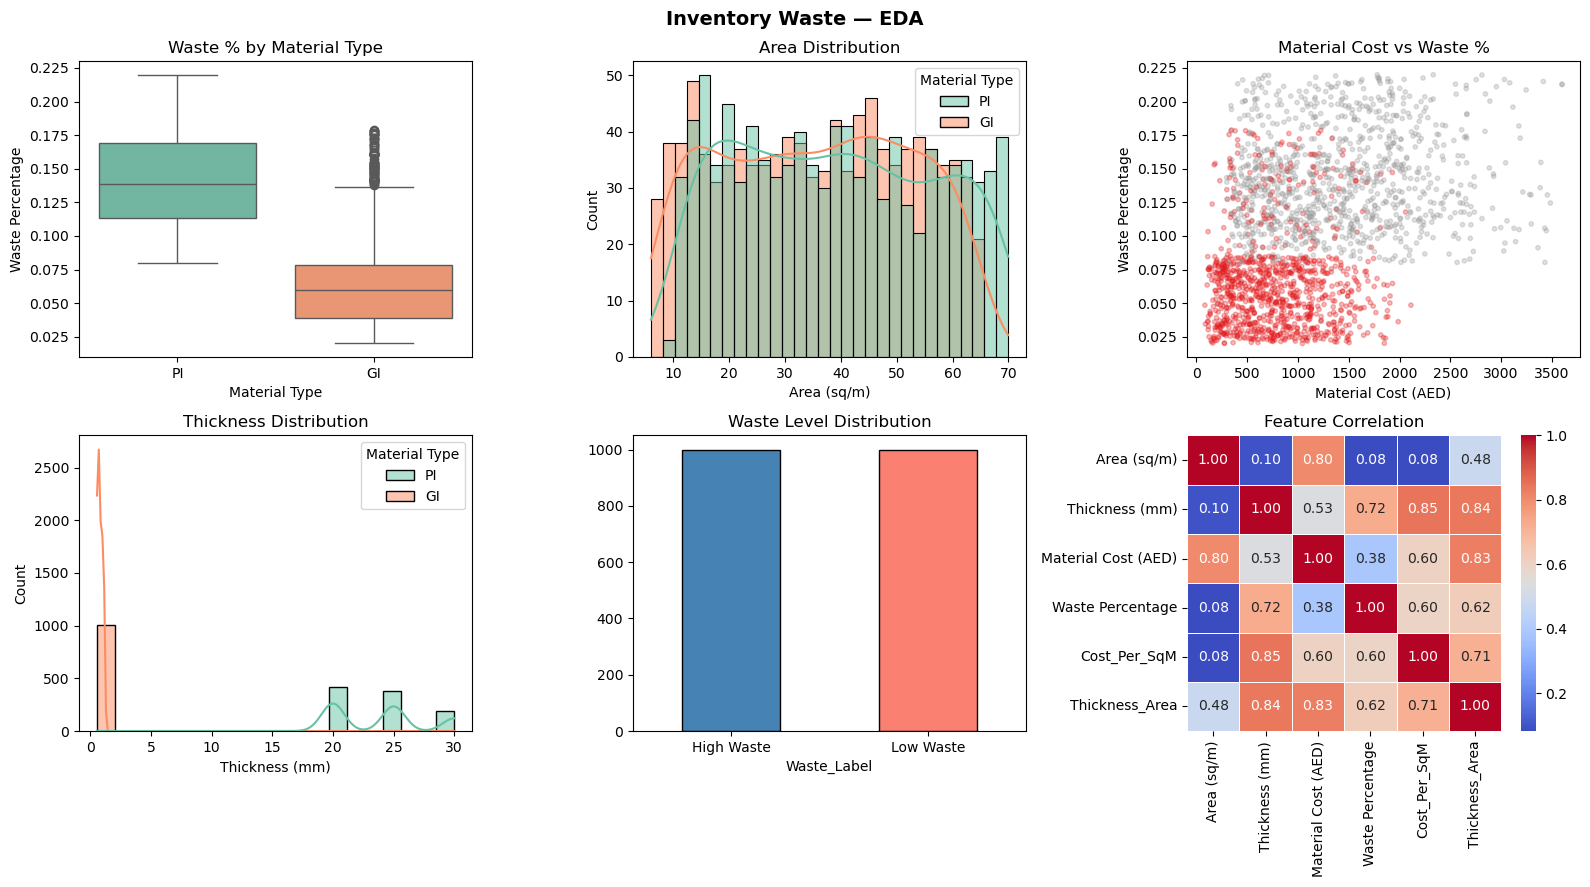

In [26]:
print("EXPLORATORY DATA ANALYSIS")

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Inventory Waste — EDA", fontsize=14, fontweight="bold")

sns.boxplot(data=df_main, x="Material Type", y="Waste Percentage",
            palette="Set2", ax=axes[0, 0])
axes[0, 0].set_title("Waste % by Material Type")

sns.histplot(data=df_main, x="Area (sq/m)", hue="Material Type",
             bins=30, kde=True, ax=axes[0, 1], palette="Set2")
axes[0, 1].set_title("Area Distribution")

axes[0, 2].scatter(df_main["Material Cost (AED)"], df_main["Waste Percentage"],
                   c=df_main["Material_Type_Enc"], cmap="Set1", alpha=0.3, s=10)
axes[0, 2].set_xlabel("Material Cost (AED)")
axes[0, 2].set_ylabel("Waste Percentage")
axes[0, 2].set_title("Material Cost vs Waste %")

sns.histplot(data=df_main, x="Thickness (mm)", hue="Material Type",
             bins=20, kde=True, ax=axes[1, 0], palette="Set2")
axes[1, 0].set_title("Thickness Distribution")

df_main["Waste_Label"] = df_main["Waste_Level"].map({0: "Low Waste", 1: "High Waste"})
df_main["Waste_Label"].value_counts().plot(kind="bar", ax=axes[1, 1],
                                            color=["steelblue", "salmon"],
                                            edgecolor="black")
axes[1, 1].set_title("Waste Level Distribution")
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=0)

corr_cols = ["Area (sq/m)", "Thickness (mm)", "Material Cost (AED)",
             "Waste Percentage", "Cost_Per_SqM", "Thickness_Area"]
sns.heatmap(df_main[corr_cols].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", ax=axes[1, 2], linewidths=0.5)
axes[1, 2].set_title("Feature Correlation")

plt.tight_layout()
plt.show()

## Cell 7 — Model 1: SVM — Waste Level Classification (Low vs High)

SVM MODEL → Target: Waste Level

Classification Report
              precision    recall  f1-score   support

   Low Waste       0.86      0.88      0.87       200
  High Waste       0.87      0.85      0.86       200

    accuracy                           0.86       400
   macro avg       0.87      0.86      0.86       400
weighted avg       0.87      0.86      0.86       400

5-Fold CV Accuracy      : 0.8665 ± 0.0066
ROC-AUC Score           : 0.8732


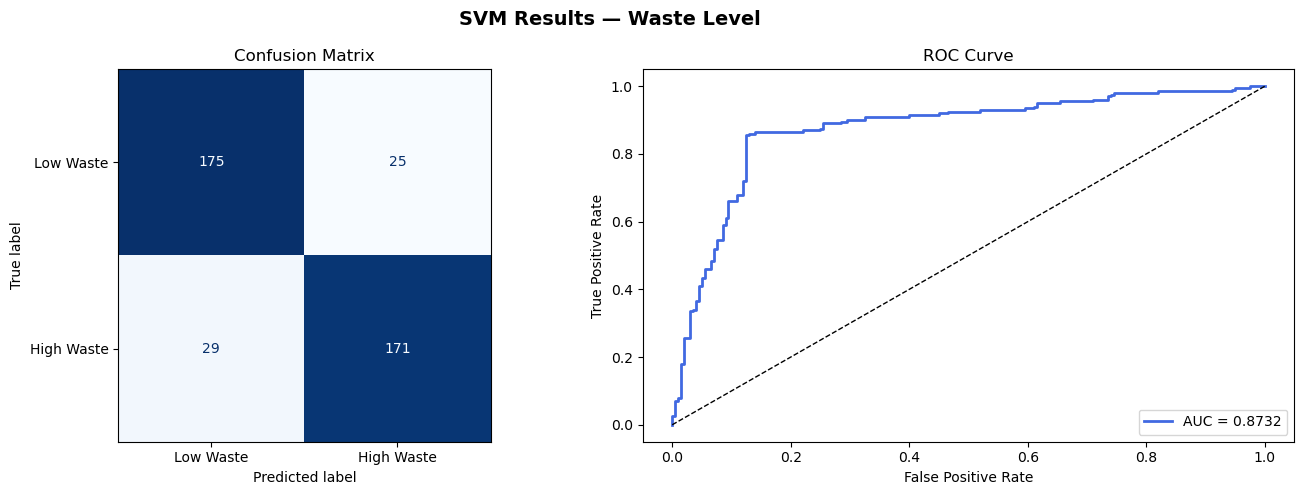

In [27]:
X1 = df_main[FEATURE_COLS + ["Material_Type_Enc"]].values
y1 = df_main["Waste_Level"].values

model_waste = train_evaluate_svm(
    X1, y1,
    target_name="Waste Level",
    class_names=["Low Waste", "High Waste"],
    tune_hyperparams=False
)

## Cell 8 — Model 2: SVM — Material Type Classification (GI vs PI)

SVM MODEL → Target: Material Type (GI vs PI)

Running GridSearchCV (this may take a moment)...
Best Params             : {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best CV Accuracy        : 1.0000

Classification Report
              precision    recall  f1-score   support

          GI       1.00      1.00      1.00       201
          PI       1.00      1.00      1.00       199

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400

5-Fold CV Accuracy      : 1.0000 ± 0.0000
ROC-AUC Score           : 1.0000


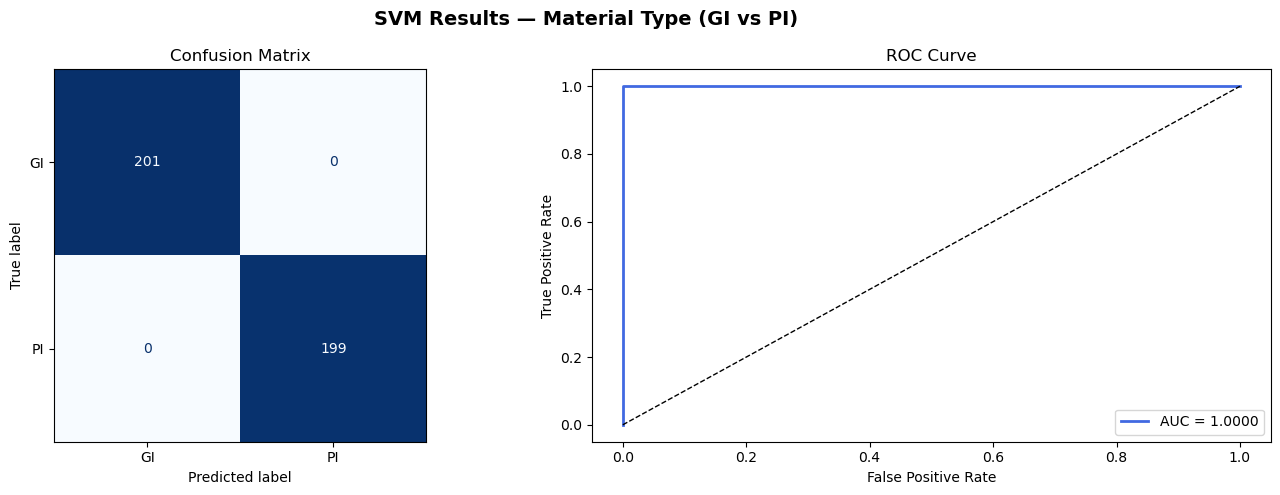

In [29]:
X2 = df_main[FEATURE_COLS_MT].values
y2 = df_main["Material_Type_Enc"].values

model_material = train_evaluate_svm(
    X2, y2,
    target_name="Material Type (GI vs PI)",
    class_names=le.classes_.tolist(),
    tune_hyperparams=True
)

## Cell 9 — Feature Importance

FEATURE IMPORTANCE

Top features for [Waste Level]:
                Feature  Coefficient  Abs_Coef
          Avg_Item_Cost     0.333455  0.333455
Raw_Material_Item_Count    -0.333455  0.333455
      Material_Type_Enc     0.333455  0.333455
         Thickness (mm)    -0.000615  0.000615
         Thickness_Area     0.000455  0.000455
    Material Cost (AED)    -0.000430  0.000430
           Cost_Per_SqM     0.000135  0.000135
            Area (sq/m)     0.000037  0.000037


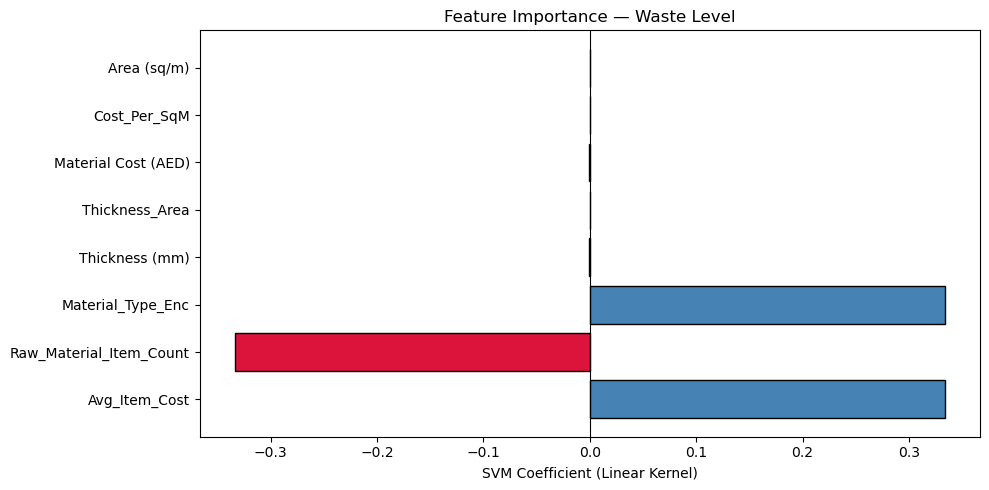


Top features for [Material Type]:
            Feature  Coefficient  Abs_Coef
     Thickness (mm)     1.200382  1.200382
     Thickness_Area     0.260609  0.260609
        Area (sq/m)    -0.005975  0.005975
Material Cost (AED)    -0.005297  0.005297
       Cost_Per_SqM     0.001145  0.001145


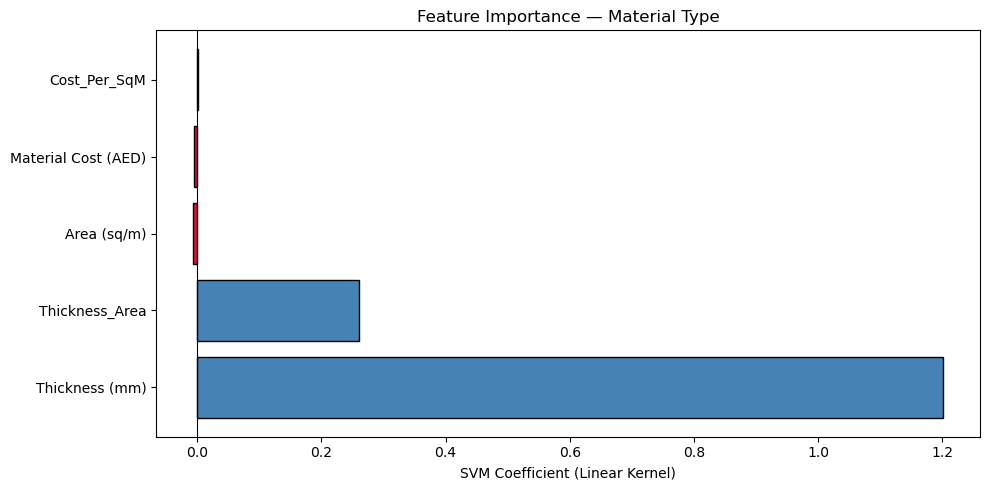

In [ ]:
print("FEATURE IMPORTANCE")

for (X, y_target, feat_names, title) in [
    (X1, y1, FEATURE_COLS + ["Material_Type_Enc"], "Waste Level"),
    (X2, y2, FEATURE_COLS_MT,                      "Material Type"),
]:
    scaler  = StandardScaler()
    X_sc    = scaler.fit_transform(X)
    lin_svm = SVC(kernel="linear", C=1, random_state=42)
    lin_svm.fit(X_sc, y_target)

    coefs = lin_svm.coef_[0]
    fi_df = pd.DataFrame({"Feature": feat_names, "Coefficient": coefs})
    fi_df["Abs_Coef"] = fi_df["Coefficient"].abs()
    fi_df = fi_df.sort_values("Abs_Coef", ascending=False)

    print(f"\nTop features for [{title}]:")
    print(fi_df.to_string(index=False))

    plt.figure(figsize=(10, 5))
    colors = ["crimson" if c < 0 else "steelblue" for c in fi_df["Coefficient"]]
    plt.barh(fi_df["Feature"], fi_df["Coefficient"], color=colors, edgecolor="black")
    plt.axvline(0, color="black", lw=0.8)
    plt.xlabel("SVM Coefficient (Linear Kernel)")
    plt.title(f"Feature Importance — {title}")
    plt.tight_layout()
    plt.show()

## Cell 10 — Save Model

In [33]:
import joblib
joblib.dump(model_waste,                "../models/svm_waste_model.pkl")
joblib.dump(model_material,             "../models/svm_material_model.pkl")
joblib.dump(le,                         "../models/svm_label_encoder.pkl")
joblib.dump({
    "gi_avg_cost":  gi_avg_unit_cost,
    "pi_avg_cost":  pi_avg_cost,
    "gi_raw_count": gi_raw_count,
    "pi_raw_count": pi_raw_count,
}, "../models/svm_meta.pkl")

['../models/svm_meta.pkl']